## 6. Missing piece non linearity
 

### 6.1 Re-creating the non linear data

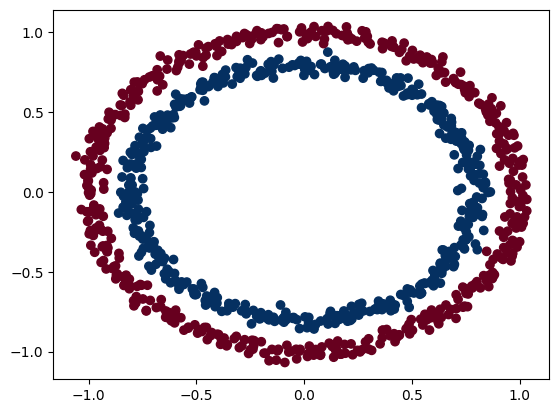

In [1]:
#Make and plot the data
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
import numpy as np
n_samples = 1000 

X,y = make_circles(n_samples,noise = 0.03,random_state= 42)

plt.scatter(X[:,0],X[:,1],c=y,cmap=plt.cm.RdBu);


In [2]:
#Check data type and conevrt to tensors if it is not in tensor
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]], shape=(1000, 2))

In [3]:
#converting the data to tensors and then to train and test splits
import torch  
from sklearn.model_selection import train_test_split
X = torch.from_numpy(X).type(torch.float)
y= torch.from_numpy(y).type(torch.float)



#Split into train and test sets
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)
X_train[:5] , y_test[:5]


(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 1., 0., 1.]))

## 6.2 Building a model with non linearity

In [4]:
#device agnostic code
import torch 
from torch import nn
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [5]:
#Build a model with non-linear activation function
from torch import nn
class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(in_features = 2 , out_features = 10)
        self.layer2 = nn.Linear(in_features = 10, out_features = 10)
        self.layer3 = nn.Linear(in_features =10 , out_features = 1)
        self.relu = nn.ReLU() #Relu is a non linear activation function
        self.sigmoid = nn.Sigmoid()
    def forward(self,x):
        return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))

        #(input)layer 1 -> relu -> layer2 -> relu -> layer3(ouptut)



In [6]:
model_3 = CircleModelV2().to(device)
model_3

CircleModelV2(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
)

In [7]:
#setup loss and optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_3.parameters(),lr = 0.1)


### 6.3 Training a model with non linearity

In [8]:
#Accuracy fucntion
def accuracy_fn(y_true,y_pred):
    correct = torch.eq(y_true,y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc 

In [9]:
#Random seed
torch.manual_seed(42)
torch.cuda.manual_seed(42)

X_train , y_train = X_train.to(device) , y_train.to(device)
X_test , y_test = X_test.to(device) , y_test.to(device)

#Loop through data
epochs = 1000
for epoch in  range(epochs):
    model_3.train()
    #1.Forward pass
    y_logits = model_3(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))
    #2calculate the loss
    loss = loss_fn(y_logits,y_train)
    acc = accuracy_fn(y_true = y_train,y_pred = y_pred)
    #3.optimizer zero grad
    optimizer.zero_grad()
    #4.Loss backward
    loss.backward()
    #5.Step the optimizer 
    optimizer.step()
    #Testing
    model_3.eval()
    with torch.inference_mode():
        test_logits = model_3(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits,y_test)
        test_acc = accuracy_fn(y_true = y_test , y_pred = test_pred)

    if epoch % 100 == 0 :
        print(f"Epoch : {epoch}| Loss : {loss:.4f} | acc : {acc:.2f}% | Test loss : {test_loss:.4f} | Test accuracy :  {test_acc:.2f}%")

Epoch : 0| Loss : 0.6956 | acc : 50.00% | Test loss : 0.6951 | Test accuracy :  50.00%
Epoch : 100| Loss : 0.6906 | acc : 53.37% | Test loss : 0.6910 | Test accuracy :  51.50%
Epoch : 200| Loss : 0.6874 | acc : 64.38% | Test loss : 0.6881 | Test accuracy :  67.00%
Epoch : 300| Loss : 0.6821 | acc : 60.25% | Test loss : 0.6822 | Test accuracy :  62.50%
Epoch : 400| Loss : 0.6757 | acc : 59.38% | Test loss : 0.6756 | Test accuracy :  63.00%
Epoch : 500| Loss : 0.6677 | acc : 59.13% | Test loss : 0.6678 | Test accuracy :  63.50%
Epoch : 600| Loss : 0.6573 | acc : 60.25% | Test loss : 0.6580 | Test accuracy :  65.00%
Epoch : 700| Loss : 0.6409 | acc : 64.38% | Test loss : 0.6447 | Test accuracy :  66.50%
Epoch : 800| Loss : 0.6119 | acc : 80.88% | Test loss : 0.6215 | Test accuracy :  79.00%
Epoch : 900| Loss : 0.5593 | acc : 97.88% | Test loss : 0.5792 | Test accuracy :  93.00%


## 6.4 Evalvuating a model trained with non-linear activation fucntions

In [10]:
#make predictions
model_3.eval()
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()

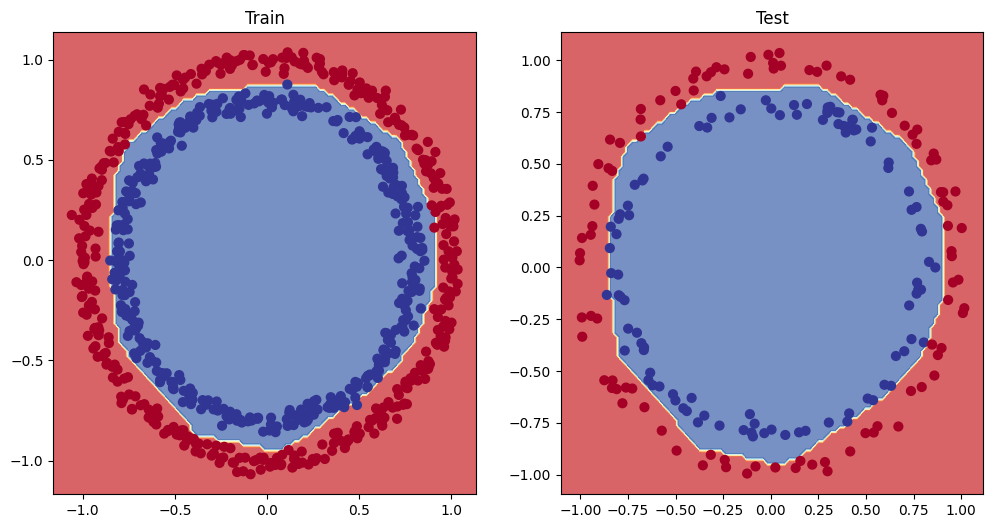

In [11]:
#plotting 

from helper_function import plot_decision_boundary,plot_predictions
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_3,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_3,X_test,y_test)

In [12]:
model_3.state_dict()

OrderedDict([('layer1.weight',
              tensor([[ 0.6215,  0.3227],
                      [-1.0703,  0.8810],
                      [ 1.0816, -0.4740],
                      [ 0.9235, -1.0817],
                      [ 0.1878,  0.4386],
                      [-0.9493, -0.1024],
                      [ 0.6241,  0.9480],
                      [-0.0225,  0.9277],
                      [-0.7040, -0.0836],
                      [ 0.0786, -0.4244]])),
             ('layer1.bias',
              tensor([ 0.6999, -0.4979, -0.4858, -0.5927,  0.4852,  0.4612, -0.0926,  0.9557,
                       0.7161,  0.6399])),
             ('layer2.weight',
              tensor([[-0.3934,  0.5901,  0.4910,  0.3379, -0.3679,  0.3793, -0.1900, -0.2778,
                        0.2509,  0.0694],
                      [ 0.1083, -0.2044,  0.0219, -0.3561,  0.1018,  0.2118, -0.4944,  0.1629,
                       -0.2104,  0.3290],
                      [-0.5415,  0.8043, -0.0733, -0.1239, -0.3180,  0.3145

### 7. Replicating non linear activation functions

In [13]:
#create a tensor
A = torch.arange(-10,10,1,dtype=torch.float32)
A.dtype

torch.float32

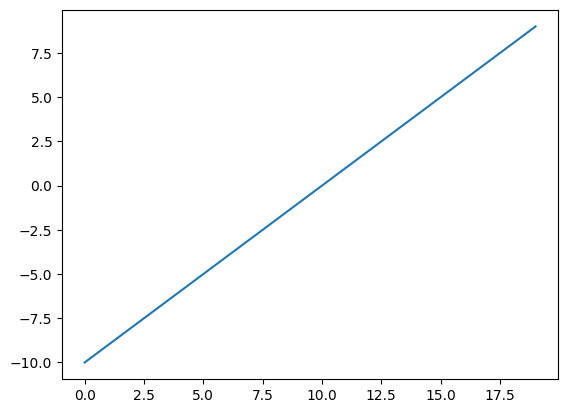

In [14]:
#Visualizing the data
plt.plot(A)

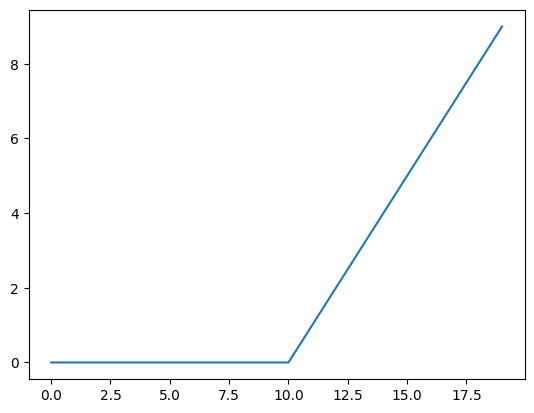

In [15]:
plt.plot(torch.relu(A))

In [16]:
#Replicating the relu function
def relu(x) -> torch.Tensor:
    return torch.maximum(torch.tensor(0),x)

relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

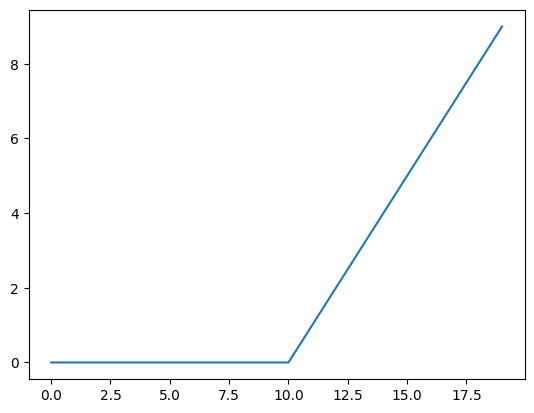

In [17]:
plt.plot(relu(A))

In [18]:
def sigmoid(x):
    return 1 / (1 + torch.exp(-x))
sigmoid(A)

tensor([4.5398e-05, 1.2339e-04, 3.3535e-04, 9.1105e-04, 2.4726e-03, 6.6929e-03,
        1.7986e-02, 4.7426e-02, 1.1920e-01, 2.6894e-01, 5.0000e-01, 7.3106e-01,
        8.8080e-01, 9.5257e-01, 9.8201e-01, 9.9331e-01, 9.9753e-01, 9.9909e-01,
        9.9966e-01, 9.9988e-01])

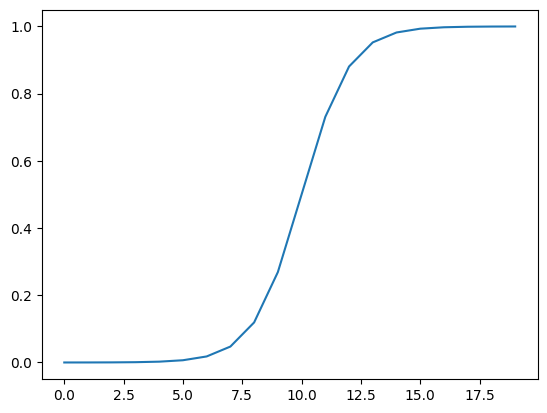

In [19]:
plt.plot(sigmoid(A))